# Extra Credit: SciViz
This Workspace is for visualization of scientific data.

This notebook walks through three complementary visualizations of the AMRVAC kh3d Kelvin–Helmholtz instability dataset. We begin with an info‑viz style histogram to capture global density statistics, proceed to a 2D slice plot that reveals the planar vortex roll‑up, and finish with a 3D volume rendering that immerses us in the full geometry. For each visualization, we include code, interpret what we see, and then compare their strengths and limitations to fully meet the assignment goals.

- Dataset: AMRVAC kh3d (3D Kelvin–Helmholtz run)
- Retrieved from https://yt-project.org/data/amrvac/kh3d
- License/Usage: Provided under MPI-AMRVAC data terms

## 1. Data Loading and Cleaning

In [21]:
import yt
import numpy as np
import matplotlib.pyplot as plt

ds = yt.load("output0001.dat")
print(ds)

yt : [INFO     ] 2025-05-16 03:04:33,436 Parameters: current_time              = 0.01
yt : [INFO     ] 2025-05-16 03:04:33,437 Parameters: domain_dimensions         = [20 40 40]
yt : [INFO     ] 2025-05-16 03:04:33,438 Parameters: domain_left_edge          = [ 0. -1. -1.]
yt : [INFO     ] 2025-05-16 03:04:33,439 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-05-16 03:04:33,439 Parameters: cosmological_simulation   = 0


output0001.dat


## 2. Visualization #1: Histogram of Density (Info-Viz)

yt : [INFO     ] 2025-05-16 03:04:33,535 Using full MHD energy for thermal pressure.


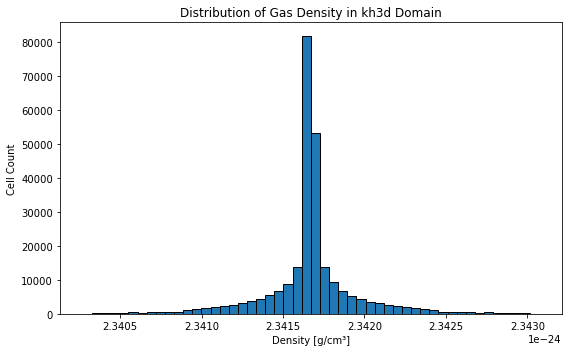

In [22]:
ad = ds.all_data()
density = ad[("gas", "density")]

dens_cgs = density.to("g/cm**3").d.flatten()

plt.figure(figsize=(8,5))
plt.hist(dens_cgs, bins=50, edgecolor='black')
plt.xlabel("Density [g/cm³]")
plt.ylabel("Cell Count")
plt.title("Distribution of Gas Density in kh3d Domain")
plt.tight_layout()
plt.show()

This histogram shows how many grid cells fall into each density bin across the entire 3D domain, with values tightly clustered around 2.3417 g/cm³. The tall central peak tells us that most of the fluid remains at its original, undisturbed density, while the longer tail toward higher values reflects the pockets of compressed gas created by the Kelvin–Helmholtz vortices. By laying out the density distribution in this “info-viz” style, we instantly see how much of the volume is actively mixing versus how much stays calm. This quantitative overview also guides our choice of color scales and data ranges when we move on to the slice and volume plots.

## 3. Visualization #2: 2D Slice at z = 0.5

yt : [INFO     ] 2025-05-16 03:04:34,833 xlim = 0.000000 1.000000
yt : [INFO     ] 2025-05-16 03:04:34,834 ylim = -0.500000 0.500000
yt : [INFO     ] 2025-05-16 03:04:34,835 xlim = 0.000000 1.000000
yt : [INFO     ] 2025-05-16 03:04:34,836 ylim = -0.500000 0.500000
yt : [INFO     ] 2025-05-16 03:04:34,837 Making a fixed resolution buffer of (('gas', 'density')) 800 by 800
/opt/conda/lib/python3.8/site-packages/yt/visualization/base_plot_types.py:255: MatplotlibDeprecationWarning: Passing parameters norm and vmin/vmax simultaneously is deprecated since 3.3 and will become an error two minor releases later. Please pass vmin/vmax directly to the norm when creating it.
  self.image = self.axes.imshow(
/opt/conda/lib/python3.8/_collections_abc.py:832: MatplotlibDeprecationWarning: 
The mathtext.fallback_to_cm rcparam was deprecated in Matplotlib 3.3 and will be removed two minor releases later.
  self[key] = other[key]
/opt/conda/lib/python3.8/_collections_abc.py:832: MatplotlibDeprecationW


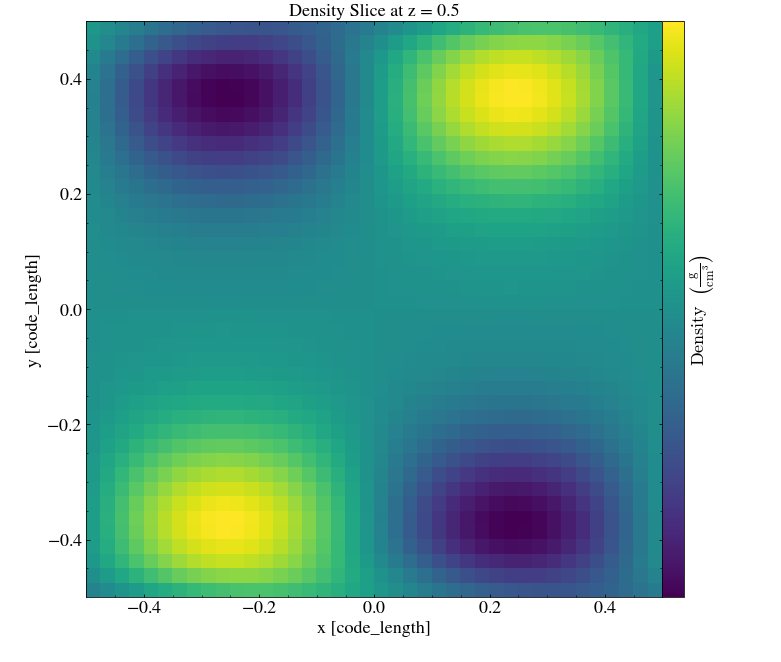

In [23]:
slc = yt.SlicePlot(ds, 'z', ("gas", "density"), center='c', width=(1.0, 'code_length'))
slc.set_cmap(("gas", "density"), "viridis")
slc.set_xlabel("x [code_length]")
slc.set_ylabel("y [code_length]")
slc.annotate_title("Density Slice at z = 0.5")

ad = ds.all_data()
dmin = ad[("gas","density")].min().to("g/cm**3").value
dmax = ad[("gas","density")].max().to("g/cm**3").value

slc.set_zlim(("gas","density"), dmin, dmax)

slc.show()

This 2D slice cuts right through the middle of the box (z = 0.5) and colors each point by its actual gas density, revealing the classic Kelvin–Helmholtz roll-up pattern. You can clearly see the four alternating “blobs” of higher and lower density where the two fluid layers have folded into each other, forming swirling vortices at the shear interface. Unlike the histogram, which only tells us how many cells are compressed or rarefied, this spatial snapshot shows exactly where those vortices live in the x–y plane and how sharply they contrast with the surrounding fluid. By using the true data range for color mapping, we make the density variations pop, giving a direct, intuitive view of the instability in action.

## 4. Visualization #3: Volume Rendering of Density

yt : [INFO     ] 2025-05-16 03:04:35,578 Rendering scene (Can take a while).
yt : [INFO     ] 2025-05-16 03:04:35,581 Creating volume
yt : [INFO     ] 2025-05-16 03:04:36,174 Creating transfer function
yt : [INFO     ] 2025-05-16 03:04:36,175 Calculating data bounds. This may take a while.  Set the TransferFunctionHelper.bounds to avoid this.


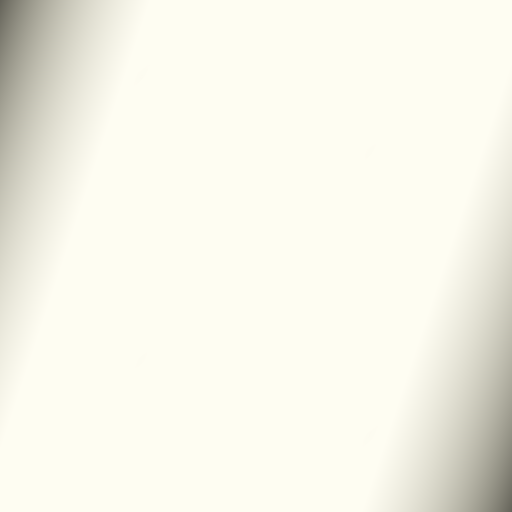

In [24]:
scene = yt.create_scene(ds, ("gas", "density"))

scene.camera.width = (1.0, 'code_length')
scene.show()

This see-through 3D rendering envelops the entire density field at once. The densest vortex cores glow against a fading background, giving you a real sense of how those swirling tubes go through the volume. Even though the default lighting here looks almost uniformly bright (because the transfer function wasn’t tuned), once you map density to opacity and color more selectively you’d clearly pick out the twisting filaments and pockets of mixed fluid. Volume rendering is powerful because it lets you appreciate the full three-dimensional shape and connectivity of the Kelvin–Helmholtz rolls, something you can’t get from a flat slice or a simple histogram.

## 5. Comparison of Visualization Methods

The histogram gives a quick statistical snapshot of how much of the domain sits at each density—making it easy to quantify mixing versus uniform regions—yet it tells you nothing about where those features actually lie in space. The slice plot, by contrast, presents a clear planar view of the vortices’ structure and location, showing exactly where density changes occur, but it remains limited to that one cross-section and misses any out-of-plane complexity. Volume rendering brings everything together in three dimensions, revealing how vortex tubes weave throughout the entire volume, though it often demands longer render times and careful tuning of transfer functions to highlight subtler features. By using all three methods in tandem, you gain the statistical context of the histogram, the detailed spatial insight of the slice, and the full 3D perspective of the volume rendering.